In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import pyproj
from pyproj import Transformer
from datetime import datetime, timedelta
import os, fnmatch, glob
import cmocean 
import rasterio
from rasterio.plot import show
import sys
import geopy.distance
import warnings
warnings.filterwarnings('ignore')
import pandas as pd

/home/maltem/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
from TrajectoryEvaluationTemp import StatisticalEvaluation

In [3]:
#ifiletemp     = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_temp_AIFS_ICON_AROMEArctic_ARPEGE_IFS_AROME_HRDPSN.nc'
#OMBtemp = xr.open_mfdataset(ifiletemp)
#ifiletemp     = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/updated_dataset_temp.nc'
#OMBtemp1 = xr.open_mfdataset(ifiletemp)
#OMBtemp['temp_flag_1m'] = (['tr_nr', 'time_ds'],OMBtemp1['temp_flag_1m'].values)
#OMBtemp['temp_flag_cons'] = (['tr_nr', 'time_ds'],OMBtemp1['temp_flag_cons'].values)
#OMBtemp.to_netcdf("/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_temp_full.nc")

MET-AROMEArctic
 -- choose model number  0
[-16 -14 -12 -10  -8  -6  -4  -2   0   2   4]
[1.02656007 1.32333745 1.46538804 1.77276444 2.06362565        nan]
MF-ARPEGE
 -- choose model number  6
[-16 -14 -12 -10  -8  -6  -4  -2   0   2   4]
[1.89708963 2.09132099 2.23945213 2.43966752 3.14368749 2.97895325]
MF-AROME
 -- choose model number  2
[-16 -14 -12 -10  -8  -6  -4  -2   0   2   4]
[2.32835929 2.28081207 2.5239276  2.57780425        nan        nan]
DWD-ICON
 -- choose model number  3
[-16 -14 -12 -10  -8  -6  -4  -2   0   2   4]
[0.9882372  1.00940992 1.1095429  1.27799172 1.42360965 1.87575184]
ECMWF-IFS
 -- choose model number  4
[-16 -14 -12 -10  -8  -6  -4  -2   0   2   4]
[1.41888406 1.48506586 1.69827771 1.91561441 1.97027378 1.7146878 ]
ECMWF-AIFS
 -- choose model number  5
[-16 -14 -12 -10  -8  -6  -4  -2   0   2   4]
[1.51390899 1.40409422 1.47479813 1.47556981 1.65353352 1.78253796]
ECCC-HRDPSN
 -- choose model number  1
[-16 -14 -12 -10  -8  -6  -4  -2   0   2   4]
[2.8

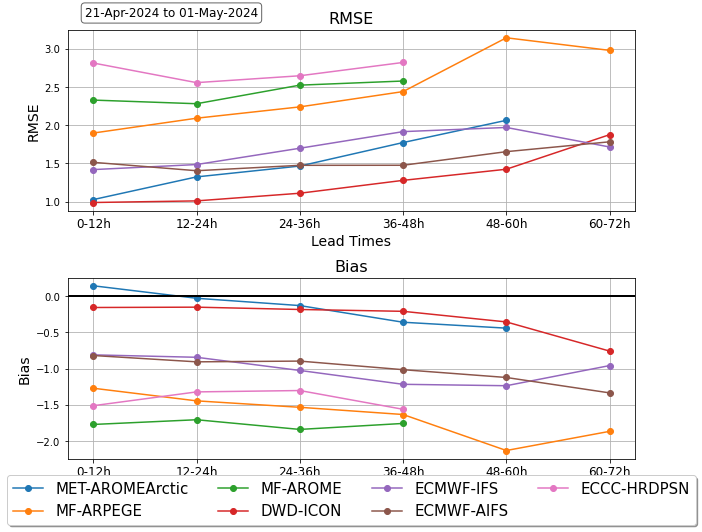

In [4]:
startdate = datetime.strptime('2024-04-21 00:00:00','%Y-%m-%d %H:%M:%S')
enddate   = datetime.strptime('2024-05-01 00:00:00','%Y-%m-%d %H:%M:%S')
ifiletemp     = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_temp_full.nc'
ifiledrift    = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_trajectories_full.nc'
i=0

leadno=6
modelALL = ['MET-AROMEArctic', 'MF-ARPEGE', 'MF-AROME', 'DWD-ICON', 'ECMWF-IFS', 'ECMWF-AIFS', 'ECCC-HRDPSN']
biasAll  = np.zeros([len(modelALL),leadno])
rmseALL  = np.zeros([len(modelALL),leadno])
stdeALL  = np.zeros([len(modelALL),leadno])

for model in modelALL[0:7]:
    print(model)
    
    s1 = StatisticalEvaluation([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32],
                           model,startdate,enddate,[1,1],ifiledrift,ifiletemp)
    s1.flag_values(rad_threshold=100)
    s1.teval_cond_err(-18, 5, 2,leadno=leadno,cond='temp',doplot=False)
    biasAll[i,:]=s1.bias
    rmseALL[i,:]=s1.rmse
    stdeALL[i,:]=s1.stde
    print(s1.rmse)
    i=i+1
      


# Define the model names and other labels for the plots
model_names =modelALL
time_steps = np.arange(0, leadno)  # Assuming you have 8 time steps or evaluations



colarray=['C0', 'C1','C2','C3','C4','C5','C6']


# Define the text to display in the box
date_range_text = f"{startdate.strftime('%d-%b-%Y')} to {enddate.strftime('%d-%b-%Y')}"

# Create the figure and subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Loop over models
for i, model in enumerate(model_names):
    # Plot RMSE for each model on the first subplot
    ax[0].plot(time_steps, rmseALL[i, :],  color=colarray[i], marker='o')
    #ax[0].plot(time_steps, stdeALL[i, :], label=model, color=colarray[i], marker='o',linestyle='--')
    # Plot Bias for each model on the second subplot
    ax[1].plot(time_steps, biasAll[i, :], label=model, marker='o')
    # Add a horizontal line at y = 0
ax[1].axhline(y=0, color='black', linestyle='-', linewidth=2)
# First subplot: RMSE
ax[0].set_title('RMSE', fontsize=16)
ax[0].set_xlabel('Lead Times', fontsize=14)
ax[0].set_ylabel('RMSE', fontsize=14)
#ax[0].legend(title="Models")
ax[0].grid(True)

# Second subplot: Bias
ax[1].set_title('Bias', fontsize=16)
ax[1].set_xlabel('Lead Times', fontsize=14)
ax[1].set_ylabel('Bias', fontsize=14)
#ax[1].legend(title="Models",fontsize=15)
ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=4,fontsize=15)
ax[1].grid(True)

# Define the custom x-axis labels
lead_times_labels = ['0-12h', '12-24h', '24-36h', '36-48h', '48-60h', '60-72h']

# Update the x-axis ticks and labels for both subplots
ax[0].set_xticks(time_steps)
ax[0].set_xticklabels(lead_times_labels, fontsize=12)
ax[1].set_xticks(time_steps)
ax[1].set_xticklabels(lead_times_labels, fontsize=12)

# Add the text box to the overall figure
fig.text(
    0.25, 0.92, date_range_text,  # Position (x, y)
    fontsize=12, ha='center', va='top',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.6)
)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.93])  # Reserve space for the text box

plt.savefig('TempEval_.'+f"{startdate.strftime('%d-%b-%Y')}to{enddate.strftime('%d-%b-%Y')}"+'.png', dpi=300)
# Show the plot
plt.show()





In [ ]:
startdate = datetime.strptime('2024-04-05 00:00:00','%Y-%m-%d %H:%M:%S')
enddate   = datetime.strptime('2024-05-05 00:00:00','%Y-%m-%d %H:%M:%S')
ifiletemp     = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/updated_dataset_temp.nc'
ifiledrift    = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_trajectories_full.nc'
i=0

leadno=6

biasAll  = np.zeros([5,leadno])
rmseALL  = np.zeros([5,leadno])
stdeALL  = np.zeros([5,leadno])

modelALL = ['MET-AROMEArctic', 'MF-ARPEGE','DWD-ICON', 'ECMWF-IFS', 'ECMWF-AIFS']
model=modelALL[4]
    
s1 = StatisticalEvaluation([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32],
                           model,startdate,enddate,[1,1],ifiledrift,ifiletemp)
s1.flag_values(rad_threshold=10)
s1.teval_cond_err(-20, 5, 4,leadno=leadno,cond='temp',doplot=True)

plt.savefig('ConditionalTemperature_'+model+'.png', dpi=300)  # Adjust 'dpi' for desired resolution

Statistical evaluation of 33 buoys
Use of model:  ECMWF-AIFS


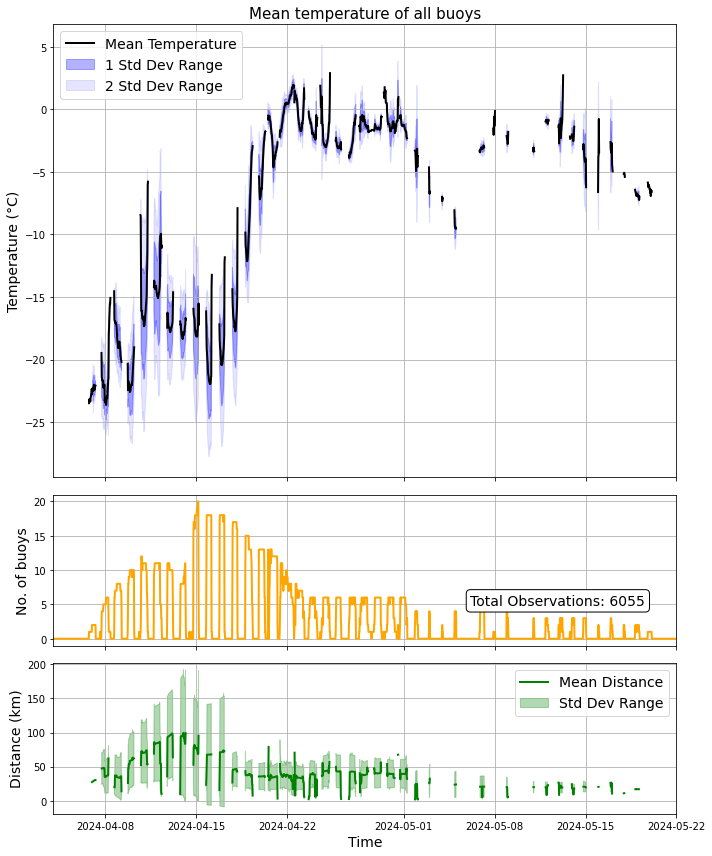

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from geopy.distance import geodesic  # For calculating distance in kilometers

# Assuming the StatisticalEvaluation class and related methods are defined elsewhere
# from your_module import StatisticalEvaluation

# Initializing parameters
buoyno = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32]
startdate = datetime.strptime('2024-04-04 00:00:00', '%Y-%m-%d %H:%M:%S')
enddate = datetime.strptime('2024-05-22 00:00:00', '%Y-%m-%d %H:%M:%S')
ifiletemp = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/updated_dataset_temp.nc'
ifiledrift = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_trajectories_full.nc'

# Instantiate the StatisticalEvaluation object
s1 = StatisticalEvaluation(buoyno, 'ECMWF-AIFS', startdate, enddate, [1, 1], ifiledrift, ifiletemp)
s1.info()
s1.flag_values(rad_threshold=100)

# Set up the parameters for the data
bmax = 32
tmax = int(np.shape(s1.OMBtemp.time_ds.values)[0])

# Initialize arrays to hold the data
temp_series_data = np.zeros([bmax, tmax])
lat_data = np.zeros([bmax, tmax])
lon_data = np.zeros([bmax, tmax])

# Process the data, handle flags and fill arrays
for buoyno in range(32):
    temp_1m = np.squeeze(s1.OMBtemp.temp_1m_calibrated[buoyno, :].values)
    lat_buoy = np.squeeze(s1.OMBtemp.lat_obs[buoyno, :].values)
    lon_buoy = np.squeeze(s1.OMBtemp.lon_obs[buoyno, :].values)
    
    flag = np.squeeze(s1.OMBtemp.temp_flag[buoyno, :].values.astype(bool))
    
    # Fill temperature data, convert from Kelvin to Celsius
    temp_series_data[buoyno, :] = temp_1m - 273.15
    temp_series_data[buoyno, flag] = np.nan  # Apply the flag
    
    # Store latitudes and longitudes, flagging them the same way as temperature
    lat_data[buoyno, :] = lat_buoy
    lon_data[buoyno, :] = lon_buoy
    lat_data[buoyno, flag] = np.nan
    lon_data[buoyno, flag] = np.nan

# Count the number of valid time series (non-flagged) at each time point
valid_series_count = np.sum(~np.isnan(temp_series_data), axis=0)

# Calculate the total number of valid observations
total_valid_observations = int(np.sum(valid_series_count))

# Calculate the ensemble mean and standard deviation at each time point, ignoring NaNs
ensemble_mean = np.nanmean(temp_series_data, axis=0)
ensemble_std = np.nanstd(temp_series_data, axis=0)

# Create a time vector (for example, using the time dimension from the dataset)
time = s1.OMBtemp.time_ds.values

# Calculate the mean distance between buoys at each time point (in kilometers)
mean_distance_km = np.zeros(tmax)
std_distance_km = np.zeros(tmax)

for t in range(tmax):
    lat_buoys_at_time = lat_data[:, t]
    lon_buoys_at_time = lon_data[:, t]
    valid_indices = ~np.isnan(lat_buoys_at_time) & ~np.isnan(lon_buoys_at_time)
    valid_lat_lon = np.column_stack((lat_buoys_at_time[valid_indices], lon_buoys_at_time[valid_indices]))
    
    if valid_lat_lon.shape[0] > 1:
        distances = [
            geodesic(valid_lat_lon[i], valid_lat_lon[j]).kilometers
            for i in range(valid_lat_lon.shape[0])
            for j in range(i + 1, valid_lat_lon.shape[0])
        ]
        mean_distance_km[t] = np.mean(distances)
        std_distance_km[t] = np.std(distances)
    else:
        mean_distance_km[t] = np.nan
        std_distance_km[t] = np.nan

# Set up the first figure (time series plots)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})

# Convert startdate and enddate to numerical time for Matplotlib
time_limited_start = np.datetime64(startdate)
time_limited_end = np.datetime64(enddate)

# Plot the ensemble mean and spread
ax1.plot(time, ensemble_mean, color='k', label='Mean Temperature', linewidth=2)
ax1.fill_between(time, ensemble_mean - ensemble_std, ensemble_mean + ensemble_std,
                 color='blue', alpha=0.3, label='1 Std Dev Range')
ax1.fill_between(time, ensemble_mean - 2 * ensemble_std, ensemble_mean + 2 * ensemble_std,
                 color='blue', alpha=0.1, label='2 Std Dev Range')
ax1.set_ylabel('Temperature (°C)',fontsize=14)
ax1.set_title('Mean temperature of all buoys',fontsize=15)
ax1.legend(fontsize=14)
ax1.set_xlim([time_limited_start, time_limited_end])  # Set time axis limits
ax1.grid(True)  # Add grid to the first subplot

# Plot the number of valid (non-flagged) time series
ax2.plot(time, valid_series_count, color='orange', label='Valid Time Series', linewidth=2)
ax2.set_ylabel('No. of buoys',fontsize=14)
#ax2.legend()
ax2.set_xlim([time_limited_start, time_limited_end])  # Set time axis limits
ax2.grid(True)  # Add grid to the second subplot

# Add total valid observations as a text box
ax2.text(0.95, 0.25, f"Total Observations: {total_valid_observations}", transform=ax2.transAxes,
         fontsize=14, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='black'))

# Plot the mean distance between buoys over time
ax3.plot(time, mean_distance_km, color='green', label='Mean Distance', linewidth=2)
ax3.fill_between(time, mean_distance_km - std_distance_km, mean_distance_km + std_distance_km,
                 color='green', alpha=0.3, label='Std Dev Range')
ax3.set_xlabel('Time',fontsize=14)
ax3.set_ylabel('Distance (km)',fontsize=14)
ax3.legend(fontsize=14)
ax3.set_xlim([time_limited_start, time_limited_end])  # Set time axis limits
ax3.grid(True)  # Add grid to the third subplot

# Display the time series plots
plt.tight_layout()
plt.savefig('Overview_MeanTempAndBuoys.png', dpi=300)  # Adjust 'dpi' for desired resolution
plt.show()


In [11]:
ds  = xr.open_mfdataset(ifiletemp)
              

In [9]:
print(idata)

<xarray.Dataset>
Dimensions:                      (tr_nr: 33, time_ds: 2929, model: 7, lt_int: 8)
Coordinates:
  * tr_nr                        (tr_nr) int64 1 2 3 4 6 7 ... 29 30 31 32 34 35
  * time_ds                      (time_ds) datetime64[ns] 2024-04-01 ... 2024...
  * model                        (model) object 'MET-AROMEArctic' ... 'MF-ARP...
  * lt_int                       (lt_int) object ']0_12]' ... ']84_96]'
Data variables: (12/31)
    lat_obs                      (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    lon_obs                      (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    temp_1m_calibrated           (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    temp_10cm_calibrated         (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    temp_snowsurface_calibrated  (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    temp_s

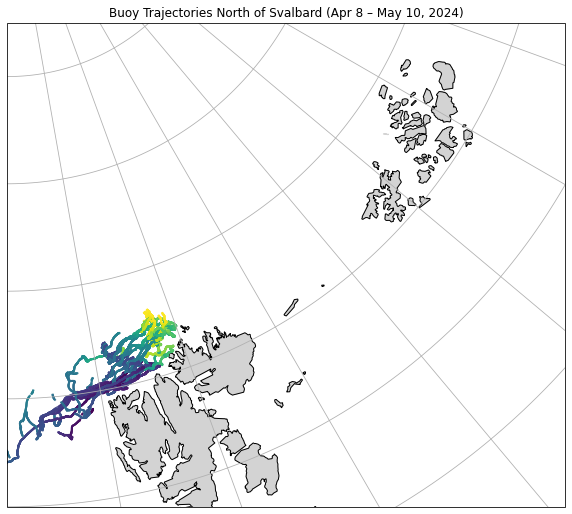

In [12]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize

# Load your dataset
# ds = xr.open_dataset("your_dataset.nc")  # if not already loaded

# Time selection
start = np.datetime64("2024-04-08")
end   = np.datetime64("2024-05-10")

ds_sub = ds.sel(time_ds=slice(start, end))

# Set up map
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo())
ax.set_extent([0, 60, 78, 84], crs=ccrs.PlateCarree())  # Adjust as needed
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.LAND, color='lightgray')
ax.gridlines(draw_labels=False)

# Colormap and normalization for fading
cmap = get_cmap("viridis")
norm = Normalize(vmin=0, vmax=ds_sub.time_ds.size)

# Plot each trajectory
for i, tr in enumerate(ds_sub.tr_nr.values):
    lats = ds_sub.lat_obs.sel(tr_nr=tr).values
    lons = ds_sub.lon_obs.sel(tr_nr=tr).values
    
    for j in range(len(ds_sub.time_ds) - 1):
        lat_pair = lats[j:j+2]
        lon_pair = lons[j:j+2]
        
        # Skip if any value is NaN
        if np.any(np.isnan(lat_pair)) or np.any(np.isnan(lon_pair)):
            continue
        
        ax.plot(lon_pair, lat_pair,
                transform=ccrs.PlateCarree(),
                color=cmap(norm(j)),
                linewidth=2,
                alpha=0.8)

plt.title("Buoy Trajectories North of Svalbard (Apr 8 – May 10, 2024)")
plt.show()


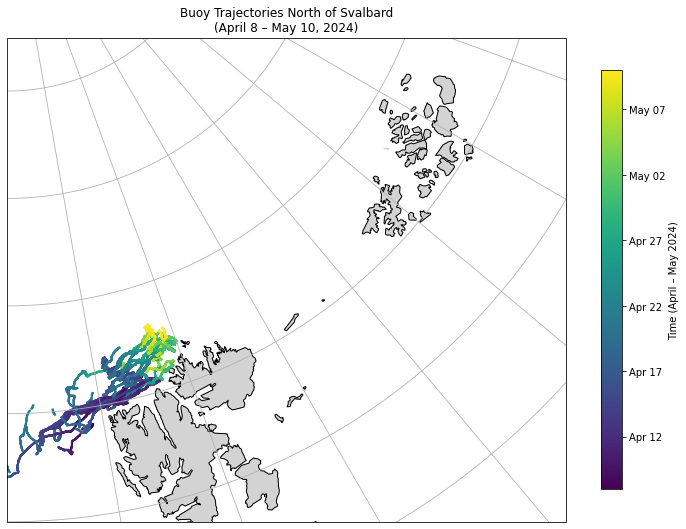

In [13]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
import matplotlib.dates as mdates

# Time selection
start = np.datetime64("2024-04-08")
end   = np.datetime64("2024-05-10")
ds_sub = ds.sel(time_ds=slice(start, end))

# Map setup
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo())
ax.set_extent([0, 60, 78, 84], crs=ccrs.PlateCarree())  # Adjust for Svalbard
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.LAND, color='lightgray')
ax.gridlines(draw_labels=False)

# Time as numeric for colormap
time_values = ds_sub.time_ds.values
time_nums = mdates.date2num(time_values)  # Convert to numeric
norm = Normalize(vmin=time_nums[0], vmax=time_nums[-1])
cmap = get_cmap("viridis")

# Plot trajectories
for tr in ds_sub.tr_nr.values:
    lats = ds_sub.lat_obs.sel(tr_nr=tr).values
    lons = ds_sub.lon_obs.sel(tr_nr=tr).values
    
    for j in range(len(time_values) - 1):
        lat_pair = lats[j:j+2]
        lon_pair = lons[j:j+2]
        if np.any(np.isnan(lat_pair)) or np.any(np.isnan(lon_pair)):
            continue
        ax.plot(lon_pair, lat_pair,
                transform=ccrs.PlateCarree(),
                color=cmap(norm(time_nums[j])),
                linewidth=2,
                alpha=0.9)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.05, shrink=0.6)
cbar.set_label("Time (April – May 2024)")
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.title("Buoy Trajectories North of Svalbard\n(April 8 – May 10, 2024)")
plt.tight_layout()
plt.show()


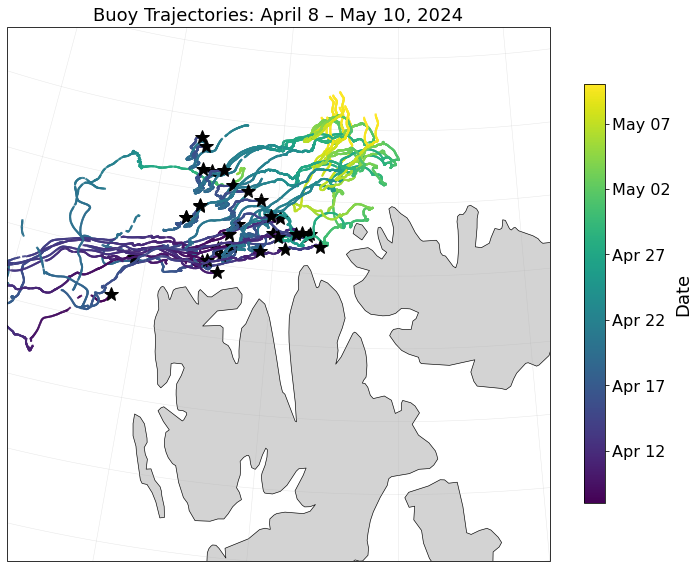

In [21]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
import matplotlib.dates as mdates

# Subset dataset in time
start = np.datetime64("2024-04-08")
end = np.datetime64("2024-05-10")
ds_sub = ds.sel(time_ds=slice(start, end))

# Convert time to numeric for colormap mapping
time_values = ds_sub.time_ds.values
time_nums = mdates.date2num(time_values)
norm = Normalize(vmin=time_nums[0], vmax=time_nums[-1])
cmap = get_cmap("viridis")

# Define projection with central longitude at 20°E
proj = ccrs.NorthPolarStereo(central_longitude=20)

# Set up the figure and map
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=proj)
ax.set_extent([7, 25, 78, 81.5], crs=ccrs.PlateCarree())  # Svalbard focus

# Add map features
ax.add_feature(cfeature.LAND.with_scale('50m'), color='lightgray')
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle=":", linewidth=0.4)
ax.gridlines(draw_labels=False, linewidth=0.5, alpha=0.3)

for tr in ds_sub.tr_nr.values:
    lats = ds_sub.lat_obs.sel(tr_nr=tr).values
    lons = ds_sub.lon_obs.sel(tr_nr=tr).values

    # Plot trajectory line segments
    for j in range(len(time_values) - 1):
        lat_pair = lats[j:j+2]
        lon_pair = lons[j:j+2]
        if np.any(np.isnan(lat_pair)) or np.any(np.isnan(lon_pair)):
            continue
        
        ax.plot(lon_pair, lat_pair,
                transform=ccrs.PlateCarree(),
                color=cmap(norm(time_nums[j])),
                linewidth=2,
                alpha=0.9)

    # Plot the start point (first valid point)
    valid = ~np.isnan(lats) & ~np.isnan(lons)
    if np.any(valid):
        start_idx = np.argmax(valid)  # first True
        ax.plot(lons[start_idx], lats[start_idx],
                marker='*', color='black', markersize=14,
                transform=ccrs.PlateCarree(),
                label='_nolegend_')  # prevent multiple legend entries

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.05, shrink=0.6)
cbar.set_label("Date", fontsize=18)
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
cbar.ax.tick_params(labelsize=16)


plt.title("Buoy Trajectories: April 8 – May 10, 2024", fontsize=18)
plt.tight_layout()

# Save as PDF (high-resolution)
plt.savefig("svalbard_trajectories.pdf", format='pdf', dpi=300)

plt.show()

